# Evaluación final
La fase de evaluación final se concibe como un ejercicio de síntesis donde recuperamos las segmentaciones obtenidas en los tres experimentos independientes. 

Al visualizar los resultados de forma simultánea en el espacio de componentes principales, podemos confirmar visualmente cómo el Gaussian Mixture Model logra el equilibrio ideal: evita la rigidez geométrica de K-Means y la fragmentación excesiva de HDBSCAN. 

Esta comparativa es la prueba técnica que justifica la elección de GMM, mostrando cómo las "capas" de probabilidad capturan mejor la progresión de valor de los clientes que las particiones por distancia o densidad pura.

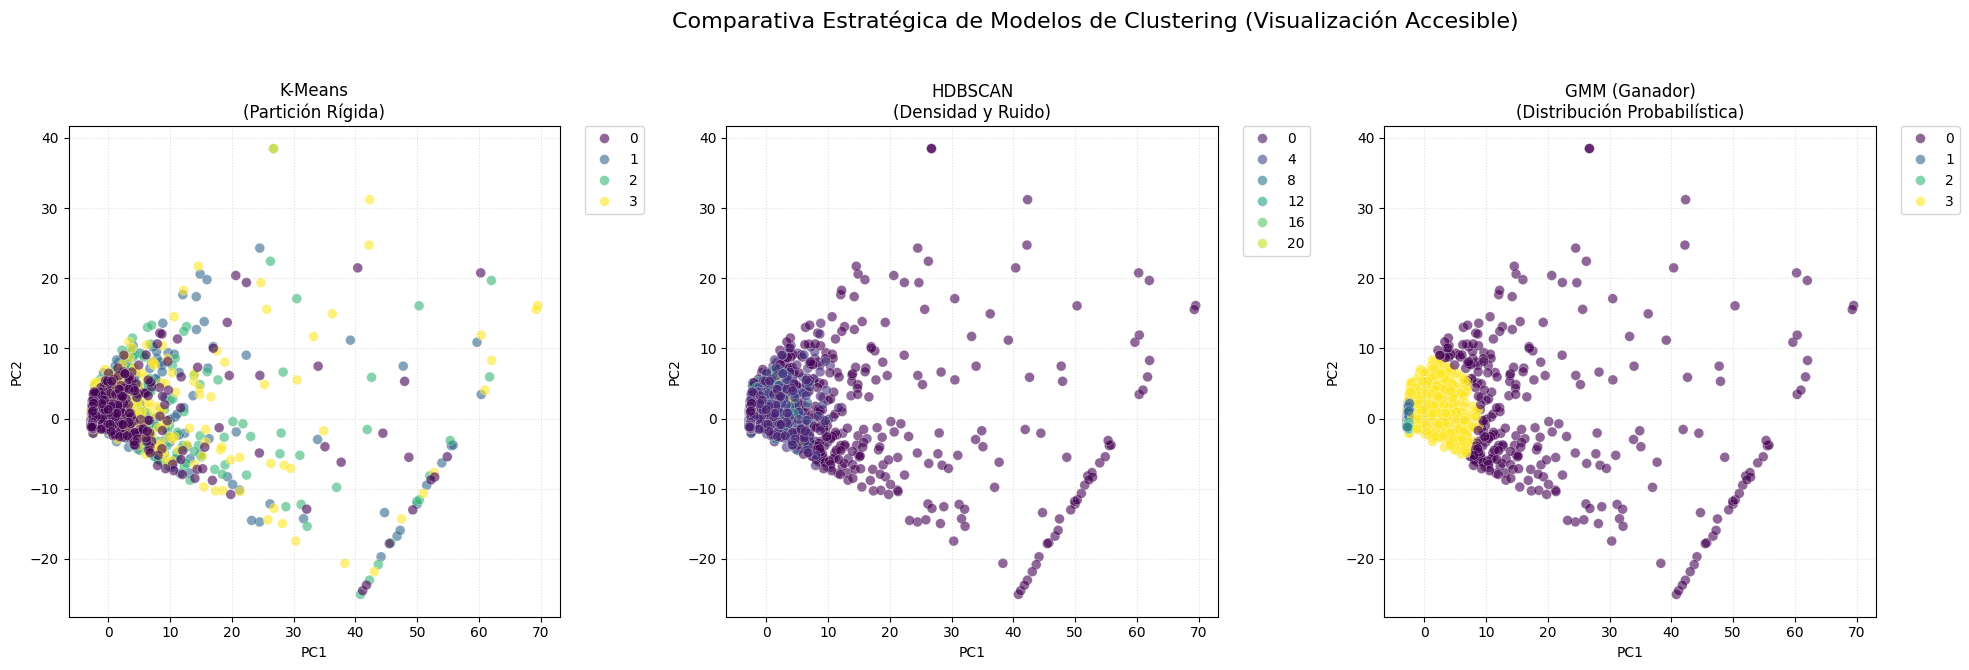

In [1]:
# 8.1. Carga de resultados para comparación
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [INFO] Cargamos los archivos generados en cada notebook
base_dir = '../../..'
df_km = pd.read_csv(f'{base_dir}/data/processed/data_kmeans_results.csv')
df_hd = pd.read_csv(f'{base_dir}/data/processed/data_hdbscan_results.csv')
df_gmm = pd.read_csv(f'{base_dir}/data/processed/data_clustering_gmm_final.csv')

# [INFO] Unificamos etiquetas en un solo DataFrame para facilitar el plot
df_eval = df_km[['PC1', 'PC2', 'Cluster_KM']].copy()
df_eval['Cluster_HDBSCAN'] = df_hd['Cluster_HDBSCAN_v2']
df_eval['Cluster_GMM'] = df_gmm['Cluster_GMM']

# 8.2. Generación del Panel Comparativo
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# [INFO] Configuración común para mejorar la visibilidad
plot_params = {
    'palette': 'viridis',
    'alpha': 0.6,
    's': 50,
    'edgecolor': 'w',
    'linewidth': 0.3
}

# [INFO] Subplot K-Means
sns.scatterplot(data=df_eval, x='PC1', y='PC2', hue='Cluster_KM', ax=axes[0], **plot_params)
axes[0].set_title('K-Means\n(Partición Rígida)')

# [INFO] Subplot HDBSCAN 
# Al usar viridis aquí, los 23 clústeres se distinguen por brillo/luminosidad
sns.scatterplot(data=df_eval, x='PC1', y='PC2', hue='Cluster_HDBSCAN', ax=axes[1], **plot_params)
axes[1].set_title('HDBSCAN\n(Densidad y Ruido)')

# [INFO] Subplot GMM
sns.scatterplot(data=df_eval, x='PC1', y='PC2', hue='Cluster_GMM', ax=axes[2], **plot_params)
axes[2].set_title('GMM (Ganador)\n(Distribución Probabilística)')

# [INFO] Ajustes estéticos finales
plt.suptitle('Comparativa Estratégica de Modelos de Clustering (Visualización Accesible)', fontsize=16)
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
plt.show()